In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/weather-type-classification")

print("Path to dataset files:", path)

g:\DO_TOUCH\Programmes\.normal_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 186k/186k [00:00<00:00, 227kB/s]

Extracting files...
Path to dataset files: C:\Users\saran\.cache\kagglehub\datasets\nikhil7280\weather-type-classification\versions\1


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv("weather_classification_data.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [3]:
X = df.drop(columns=['Weather Type'])
y = df['Weather Type']

numeric_features = [
    'Temperature', 
    'Humidity', 
    'Wind Speed', 
    'Precipitation (%)', 
    'Atmospheric Pressure', 
    'UV Index', 
    'Visibility (km)'
]

categorical_features = [
    'Cloud Cover', 
    'Season', 
    'Location'
]

In [4]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

In [5]:
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("Random Forest Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred))

Random Forest Confusion Matrix
[[908  52  16  14]
 [ 57 901  17  15]
 [ 34  26 904  26]
 [ 55  17  19 899]]

Random Forest Classification Report
              precision    recall  f1-score   support

      Cloudy       0.86      0.92      0.89       990
       Rainy       0.90      0.91      0.91       990
       Snowy       0.95      0.91      0.93       990
       Sunny       0.94      0.91      0.92       990

    accuracy                           0.91      3960
   macro avg       0.91      0.91      0.91      3960
weighted avg       0.91      0.91      0.91      3960



In [16]:
encoded_cat_features = model_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'] .get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_cat_features)
importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance Ranking")
print(feature_importance_df.head(10).to_string(index=False))


Feature Importance Ranking
             Feature  Importance
         Temperature    0.198907
     Visibility (km)    0.142151
   Precipitation (%)    0.131386
            UV Index    0.125407
Atmospheric Pressure    0.115515
   Cloud Cover_clear    0.086262
            Humidity    0.055631
       Season_Winter    0.038127
          Wind Speed    0.036760
Cloud Cover_overcast    0.019324


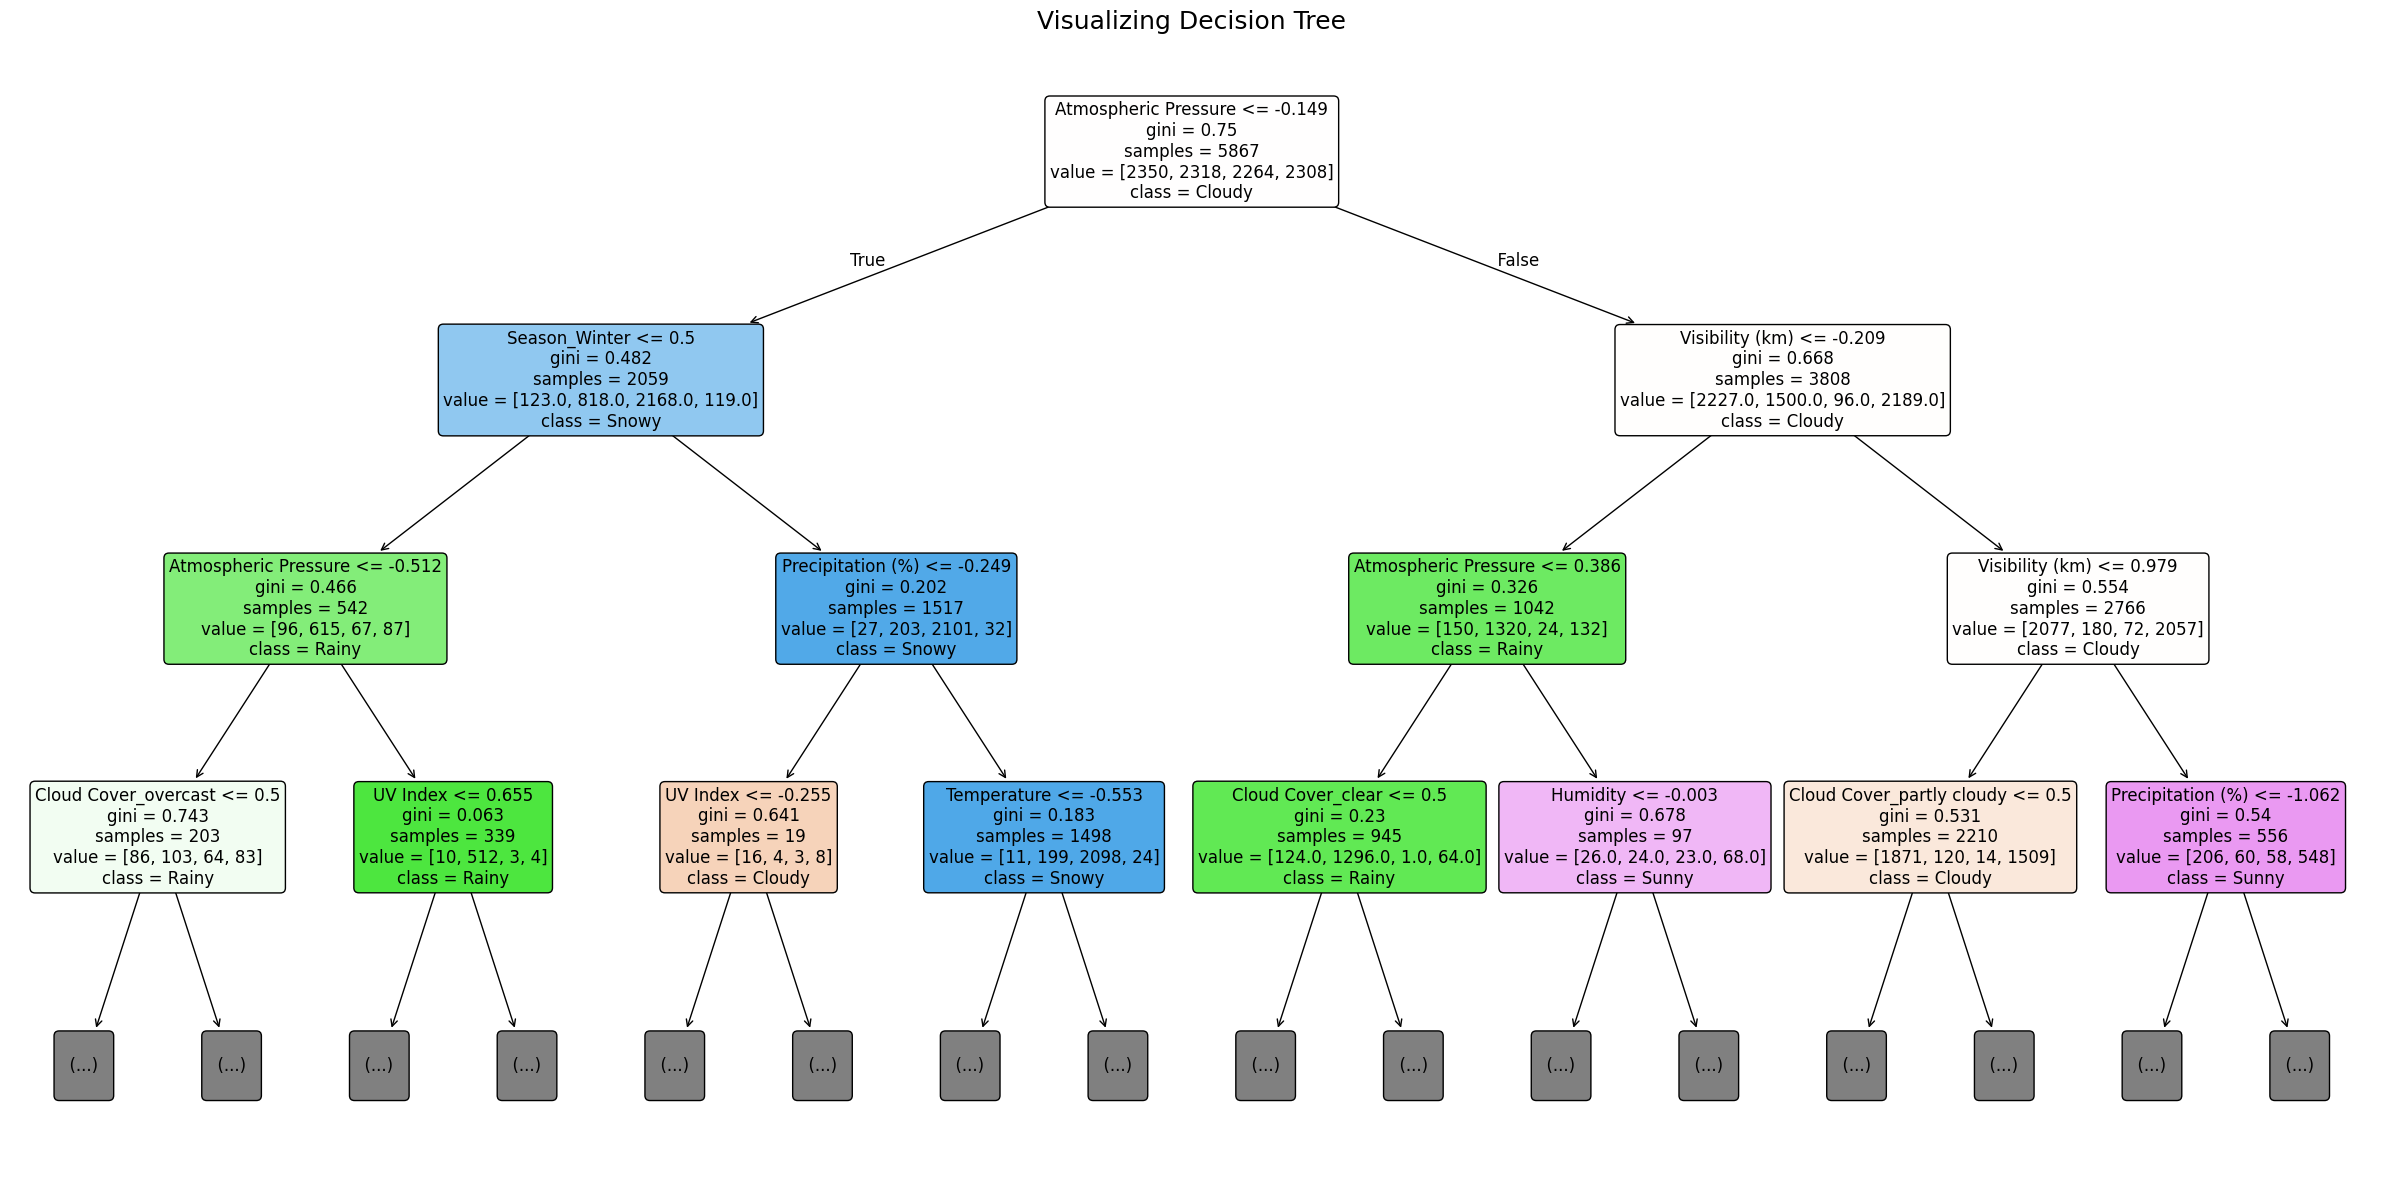

In [23]:
rf_classifier = model_pipeline.named_steps['classifier']

tree = rf_classifier.estimators_[9]

plt.figure(figsize=(24, 12))

plot_tree(
    tree, 
    feature_names=all_features,        
    class_names=rf_classifier.classes_,
    filled=True,                       
    rounded=True,                      
    max_depth=3,                       
    fontsize=12
)

plt.title("Visualizing Decision Tree", fontsize=18)
plt.tight_layout()
plt.show()